In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle configured successfully!")

Kaggle configured successfully!


In [ ]:
!kaggle datasets download -d murtozalikhon/brain-tumor-multimodal-image-ct-and-mri

Dataset URL: https://www.kaggle.com/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri
License(s): CC-BY-NC-SA-4.0
100% 361M/361M [00:06<00:00, 60.7MB/s]



In [ ]:
!ls -lh

total 361M
-rw-r--r-- 1 root root 361M Dec  3  2024 brain-tumor-multimodal-image-ct-and-mri.zip
drwxr-xr-x 1 root root 4.0K Aug 10 13:31 sample_data


In [ ]:
!mkdir -p /content/brain_dataset
!unzip -q brain-tumor-multimodal-image-ct-and-mri.zip -d /content/brain_dataset

In [ ]:
import os

for root, dirs, files in os.walk("/content/brain_dataset"):
    level = root.replace("/content/brain_dataset", "").count(os.sep)

    if level <= 3:
        print("  " * level + os.path.basename(root) + "/")

brain_dataset/
  Dataset/
    Brain Tumor CT scan Images/
      Healthy/
      Tumor/
    Brain Tumor MRI images/
      Healthy/
      Tumor/


In [ ]:
import os

base = "/content/brain_dataset/Dataset"

ct_healthy = os.path.join(
    base,
    "Brain Tumor CT scan Images",
    "Healthy"
)

ct_tumor = os.path.join(
    base,
    "Brain Tumor CT scan Images",
    "Tumor"
)

mri_healthy = os.path.join(
    base,
    "Brain Tumor MRI images",
    "Healthy"
)

mri_tumor = os.path.join(
    base,
    "Brain Tumor MRI images",
    "Tumor"
)

def count_images(folder):
    extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith(extensions)
    ])

print("CT Healthy :", count_images(ct_healthy))
print("CT Tumor   :", count_images(ct_tumor))
print("MRI Healthy:", count_images(mri_healthy))
print("MRI Tumor  :", count_images(mri_tumor))

CT Healthy : 2300
CT Tumor   : 2318
MRI Healthy: 2000
MRI Tumor  : 3000


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = "/content/brain_dataset/Dataset"

folders = {
    "CT Healthy": os.path.join(
        base, "Brain Tumor CT scan Images", "Healthy"
    ),
    "CT Tumor": os.path.join(
        base, "Brain Tumor CT scan Images", "Tumor"
    ),
    "MRI Healthy": os.path.join(
        base, "Brain Tumor MRI images", "Healthy"
    ),
    "MRI Tumor": os.path.join(
        base, "Brain Tumor MRI images", "Tumor"
    )
}

for name, folder in folders.items():
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    sample = os.path.join(folder, files[0])

    image = Image.open(sample)

    print(
        f"{name}: "
        f"format={image.format}, "
        f"size={image.size}, "
        f"mode={image.mode}"
    )

CT Healthy: format=PNG, size=(512, 512), mode=L
CT Tumor: format=JPEG, size=(640, 640), mode=RGB
MRI Healthy: format=JPEG, size=(750, 750), mode=RGB
MRI Tumor: format=JPEG, size=(512, 512), mode=RGB


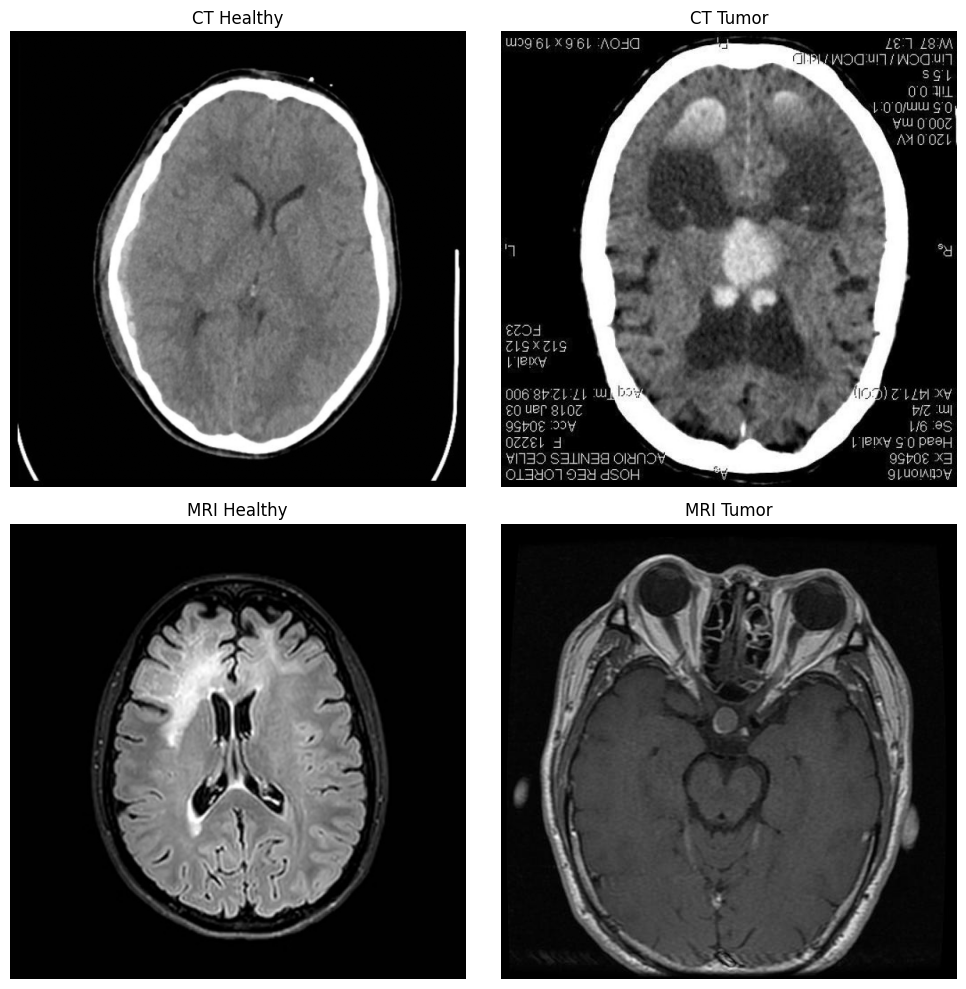

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (name, folder) in zip(axes.flat, folders.items()):

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    image_path = os.path.join(folder, files[0])
    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd

base = "/content/brain_dataset/Dataset"

data = []

# -------------------------
# MRI
# -------------------------

mri_root = os.path.join(
    base,
    "Brain Tumor MRI images"
)

for category in ["Healthy", "Tumor"]:

    folder = os.path.join(
        mri_root,
        category
    )

    for filename in os.listdir(folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            data.append({
                "filepath": os.path.join(folder, filename),
                "label": 0,
                "modality": "MRI"
            })


# -------------------------
# CT
# -------------------------

ct_root = os.path.join(
    base,
    "Brain Tumor CT scan Images"
)

for category in ["Healthy", "Tumor"]:

    folder = os.path.join(
        ct_root,
        category
    )

    for filename in os.listdir(folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            data.append({
                "filepath": os.path.join(folder, filename),
                "label": 1,
                "modality": "CT"
            })


df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["modality"].value_counts())

print("\nLabel distribution:")
print(df["label"].value_counts())

df.head()

Total images: 9618

Class distribution:
modality
MRI    5000
CT     4618
Name: count, dtype: int64

Label distribution:
label
0    5000
1    4618
Name: count, dtype: int64


,filepath,label,modality
0,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,MRI
1,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,MRI
2,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,MRI
3,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,MRI
4,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,MRI


In [ ]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df.head())

                                            filepath  label modality
0  /content/brain_dataset/Dataset/Brain Tumor MRI...      0      MRI
1  /content/brain_dataset/Dataset/Brain Tumor MRI...      0      MRI
2  /content/brain_dataset/Dataset/Brain Tumor CT ...      1       CT
3  /content/brain_dataset/Dataset/Brain Tumor CT ...      1       CT
4  /content/brain_dataset/Dataset/Brain Tumor MRI...      0      MRI


modality
MRI    5000
CT     4618
Name: count, dtype: int64


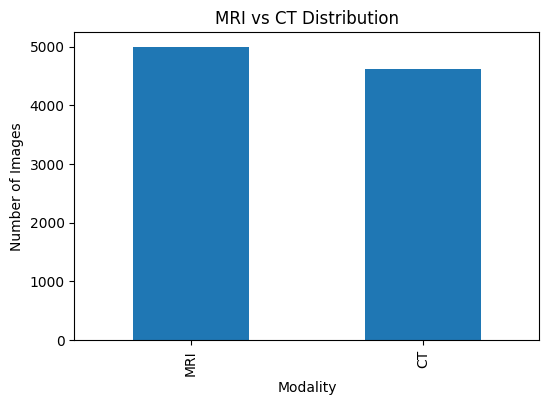

In [ ]:
print(df["modality"].value_counts())

df["modality"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("MRI vs CT Distribution")
plt.xlabel("Modality")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# Second split: divide temporary 30% into
# 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["modality"].value_counts())

print("\nValidation distribution:")
print(val_df["modality"].value_counts())

print("\nTest distribution:")
print(test_df["modality"].value_counts())

Train: 6732
Validation: 1443
Test: 1443

Train distribution:
modality
MRI    3500
CT     3232
Name: count, dtype: int64

Validation distribution:
modality
MRI    750
CT     693
Name: count, dtype: int64

Test distribution:
modality
MRI    750
CT     693
Name: count, dtype: int64


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class BrainModalityDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["filepath"]
        label = int(row["label"])

        # Load image
        image = Image.open(image_path)

        # Convert everything to RGB
        image = image.convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = BrainModalityDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainModalityDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BrainModalityDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 6732
Validation dataset: 1443
Test dataset: 1443


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 1, 0, 0, 0, 0, 1, 1, 0])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Select GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Load ImageNet-pretrained EfficientNet-B0
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Check the original classifier
print("Original classifier:")
print(model.classifier)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 41.4MB/s]


Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [ ]:
# Replace the original ImageNet classifier
# with a 2-class MRI/CT classifier

model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=2
)

# Move model to GPU
model = model.to(device)

print("New classifier:")
print(model.classifier)

New classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
import torch.optim as optim

# Loss function for 2-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Reduce learning rate if validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Learning rate: 0.0001


In [ ]:
from tqdm.auto import tqdm
import copy
import time

num_epochs = 10

best_val_loss = float("inf")
best_val_accuracy = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):

    print("=" * 60)
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("=" * 60)

    # =========================================================
    # TRAINING
    # =========================================================

    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress_bar = tqdm(
        train_loader,
        desc="Training"
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        running_correct += (
            predictions == labels
        ).sum().item()

        running_total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / running_total
    train_accuracy = running_correct / running_total

    # =========================================================
    # VALIDATION
    # =========================================================

    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0

    with torch.no_grad():

        progress_bar = tqdm(
            val_loader,
            desc="Validation"
        )

        for images, labels in progress_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_running_correct += (
                predictions == labels
            ).sum().item()

            val_running_total += labels.size(0)

    val_loss = (
        val_running_loss /
        val_running_total
    )

    val_accuracy = (
        val_running_correct /
        val_running_total
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # =========================================================
    # PRINT RESULTS
    # =========================================================

    print()
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_accuracy * 100:.2f}%")
    print(f"Val Loss        : {val_loss:.4f}")
    print(f"Val Accuracy    : {val_accuracy * 100:.2f}%")
    print(
        f"Learning Rate   : "
        f"{optimizer.param_groups[0]['lr']:.7f}"
    )

    # =========================================================
    # SAVE BEST MODEL
    # =========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "class_mapping": {
                    "MRI": 0,
                    "CT": 1
                }
            },
            "/content/modality_classifier_best.pth"
        )

        print("✅ Best model saved!")

    print()

total_time = time.time() - start_time

print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{total_time / 60:.2f} minutes"
)

Epoch 1/10


Training:   0%|          | 0/211 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd36936d260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd36936d260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Train Loss      : 0.0536
Train Accuracy  : 98.87%
Val Loss        : 0.0050
Val Accuracy    : 99.72%
Learning Rate   : 0.0001000
✅ Best model saved!

Epoch 2/10


...

Validation:   0%|          | 0/46 [00:00<?, ?it/s]


Train Loss      : 0.0005
Train Accuracy  : 99.99%
Val Loss        : 0.0041
Val Accuracy    : 99.93%
Learning Rate   : 0.0000500

Epoch 10/10


Training:   0%|          | 0/211 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]


Train Loss      : 0.0002
Train Accuracy  : 100.00%
Val Loss        : 0.0032
Val Accuracy    : 99.93%
Learning Rate   : 0.0000500

TRAINING COMPLETE
Best Validation Accuracy: 99.93%
Training Time: 9.49 minutes


In [ ]:
checkpoint = torch.load(
    "/content/modality_classifier_best.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best model loaded successfully.")
print("Saved epoch:", checkpoint["epoch"])
print(
    "Validation accuracy:",
    f"{checkpoint['val_accuracy'] * 100:.2f}%"
)

Best model loaded successfully.
Saved epoch: 5
Validation accuracy: 99.93%


In [ ]:
test_loader_clean = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Clean test loader created.")

Clean test loader created.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader_clean:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="binary"
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="binary"
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="binary"
)

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)

print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {test_precision * 100:.2f}%")
print(f"Recall    : {test_recall * 100:.2f}%")
print(f"F1 Score  : {test_f1 * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["MRI", "CT"]
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)

TEST RESULTS
Accuracy  : 99.79%
Precision : 99.71%
Recall    : 99.86%
F1 Score  : 99.78%

Classification Report:
              precision    recall  f1-score   support

         MRI       1.00      1.00      1.00       750
          CT       1.00      1.00      1.00       693

    accuracy                           1.00      1443
   macro avg       1.00      1.00      1.00      1443
weighted avg       1.00      1.00      1.00      1443

Confusion Matrix:
[[748   2]
 [  1 692]]


In [ ]:
import os

os.makedirs("/content/models", exist_ok=True)

final_model_path = "/content/models/BrainScan_Modality_Model.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_mapping": {
            "MRI": 0,
            "CT": 1
        },
        "image_size": 224,
        "model_name": "EfficientNet-B0"
    },
    final_model_path
)

print("Model saved successfully:")
print(final_model_path)

Model saved successfully:
/content/models/BrainScan_Modality_Model.pth


In [ ]:
from google.colab import files

files.download(
    "/content/models/BrainScan_Modality_Model.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import random

mri_folder = "/content/brain_dataset/Dataset/Brain Tumor MRI images/Healthy"
ct_folder = "/content/brain_dataset/Dataset/Brain Tumor CT scan Images/Healthy"

mri_files = [
    f for f in os.listdir(mri_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

ct_files = [
    f for f in os.listdir(ct_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

mri_path = os.path.join(
    mri_folder,
    random.choice(mri_files)
)

ct_path = os.path.join(
    ct_folder,
    random.choice(ct_files)
)

print("MRI test image:")
print(mri_path)

print("\nCT test image:")
print(ct_path)

MRI test image:
/content/brain_dataset/Dataset/Brain Tumor MRI images/Healthy/mri_healthy (580).jpg

CT test image:
/content/brain_dataset/Dataset/Brain Tumor CT scan Images/Healthy/ct_healthy (1100).jpg


In [ ]:
import torch
import torch.nn.functional as F
from torchvision.models import efficientnet_b0
from PIL import Image

# --------------------------------------------------
# Load model architecture
# --------------------------------------------------

test_model = efficientnet_b0(weights=None)

test_model.classifier[1] = torch.nn.Linear(
    test_model.classifier[1].in_features,
    2
)

# --------------------------------------------------
# Load our trained weights
# --------------------------------------------------

checkpoint = torch.load(
    "/content/models/BrainScan_Modality_Model.pth",
    map_location=device
)

test_model.load_state_dict(
    checkpoint["model_state_dict"]
)

test_model = test_model.to(device)
test_model.eval()

# --------------------------------------------------
# Prediction function
# --------------------------------------------------

class_names = {
    0: "MRI",
    1: "CT"
}

def predict_modality(image_path):

    image = Image.open(image_path).convert("RGB")

    image_tensor = val_test_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        output = test_model(image_tensor)

        probabilities = F.softmax(
            output,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = class_names[
        predicted.item()
    ]

    confidence = confidence.item() * 100

    return predicted_class, confidence

In [ ]:
# Test MRI
mri_prediction, mri_confidence = predict_modality(
    mri_path
)

# Test CT
ct_prediction, ct_confidence = predict_modality(
    ct_path
)

print("=" * 50)

print("MRI IMAGE")
print("Actual     : MRI")
print("Prediction :", mri_prediction)
print(f"Confidence : {mri_confidence:.2f}%")

print("-" * 50)

print("CT IMAGE")
print("Actual     : CT")
print("Prediction :", ct_prediction)
print(f"Confidence : {ct_confidence:.2f}%")

print("=" * 50)

MRI IMAGE
Actual     : MRI
Prediction : MRI
Confidence : 100.00%
--------------------------------------------------
CT IMAGE
Actual     : CT
Prediction : CT
Confidence : 99.99%


In [34]:
from google.colab import files

uploaded = files.upload()

Saving MRI_of_Human_Brain.jpg to MRI_of_Human_Brain.jpg


In [35]:
print("Uploaded files:")

for filename in uploaded.keys():
    print(filename)

Uploaded files:
MRI_of_Human_Brain.jpg


In [36]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# Class mapping
class_names = {
    0: "MRI",
    1: "CT"
}

def predict_uploaded_image(image_path):

    image = Image.open(image_path).convert("RGB")

    # Same preprocessing used during validation/testing
    image_tensor = val_test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    test_model.eval()

    with torch.no_grad():

        output = test_model(image_tensor)

        probabilities = F.softmax(
            output,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

    prediction = class_names[predicted.item()]
    confidence = confidence.item() * 100

    return prediction, confidence, image

Image: MRI_of_Human_Brain.jpg
Prediction: MRI
Confidence: 100.00%


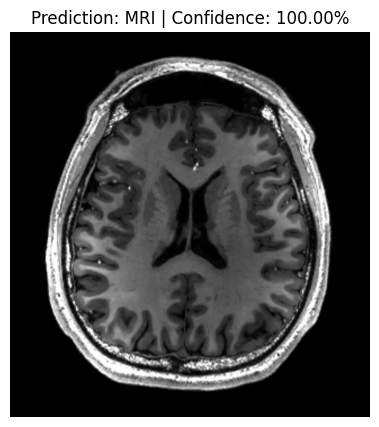

In [37]:
for filename in uploaded.keys():

    prediction, confidence, image = predict_uploaded_image(
        filename
    )

    print("=" * 60)
    print("Image:", filename)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")
    print("=" * 60)

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Prediction: {prediction} | "
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

In [38]:
from google.colab import files

uploaded = files.upload()

Saving ventricles-14-02.jpg to ventricles-14-02.jpg


In [39]:
print("Uploaded files:")

for filename in uploaded.keys():
    print(filename)

Uploaded files:
ventricles-14-02.jpg


In [40]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# Class mapping
class_names = {
    0: "MRI",
    1: "CT"
}

def predict_uploaded_image(image_path):

    image = Image.open(image_path).convert("RGB")

    # Same preprocessing used during validation/testing
    image_tensor = val_test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    test_model.eval()

    with torch.no_grad():

        output = test_model(image_tensor)

        probabilities = F.softmax(
            output,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

    prediction = class_names[predicted.item()]
    confidence = confidence.item() * 100

    return prediction, confidence, image

Image: ventricles-14-02.jpg
Prediction: CT
Confidence: 100.00%


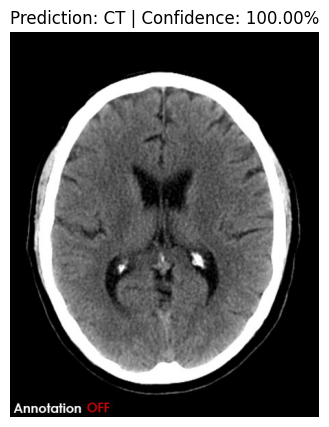

In [41]:
for filename in uploaded.keys():

    prediction, confidence, image = predict_uploaded_image(
        filename
    )

    print("=" * 60)
    print("Image:", filename)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")
    print("=" * 60)

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Prediction: {prediction} | "
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()